In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
import torch

In [2]:
data_path = "../../data/raw/T-Fillet/TF031_060"
TF_case = "TF032"
TF_Pass = f"{TF_case}_1PASS"
txt_path = f"{data_path}/{TF_case}/{TF_Pass}/{TF_case}_wellteq.txt"

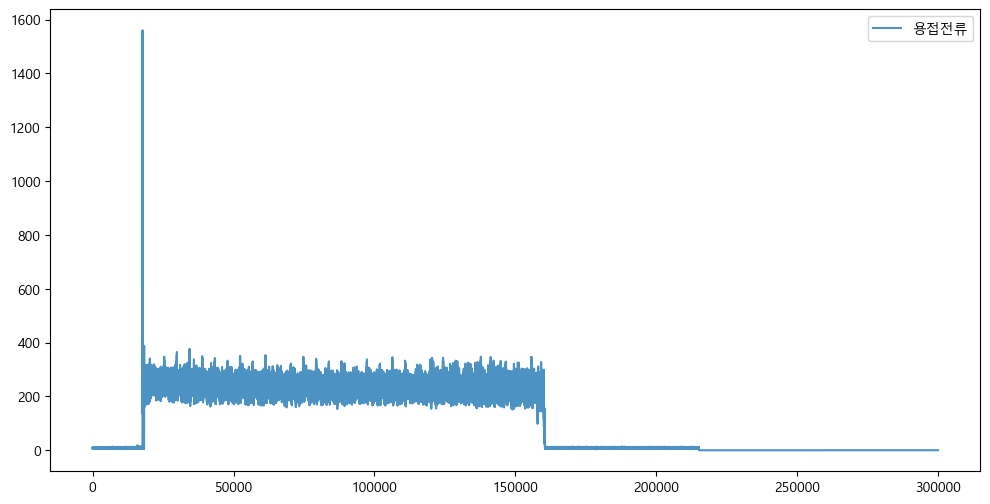

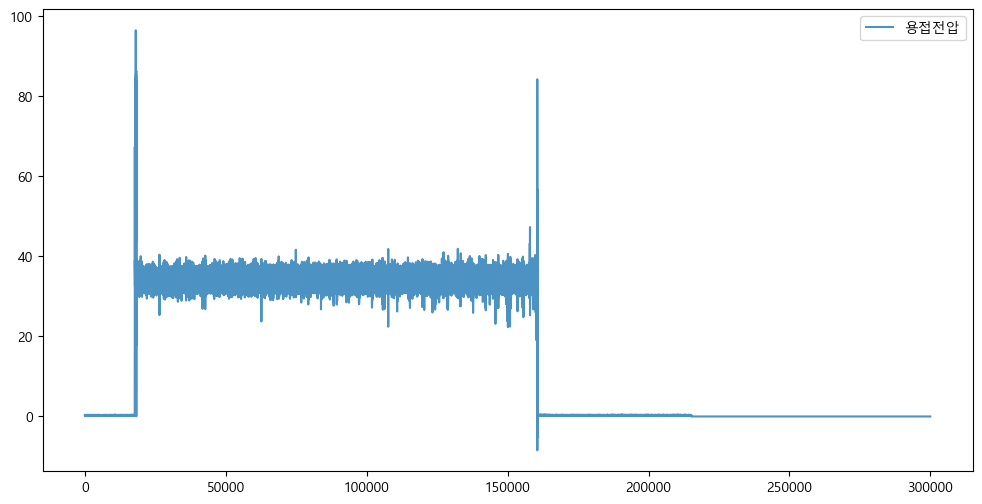

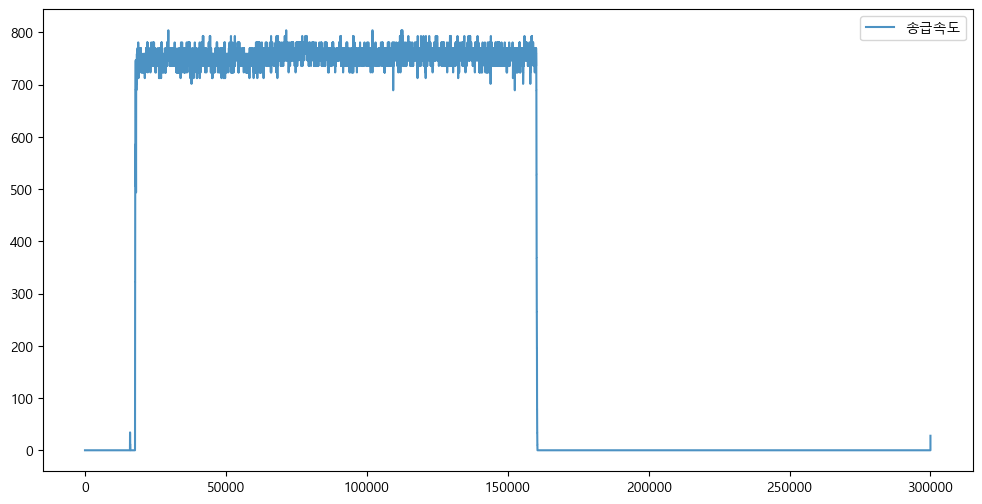

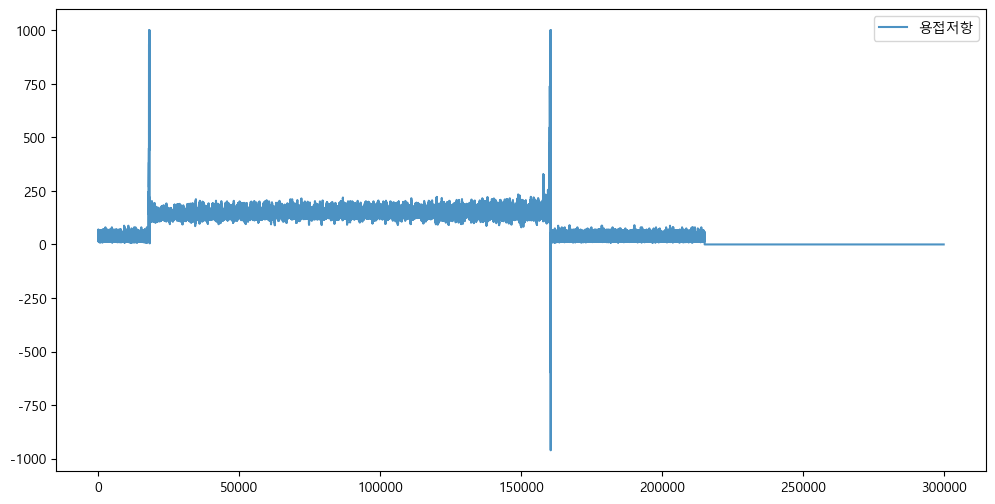

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

save_path = "../../results"

# 한글 폰트 설정 (Windows 환경의 경우 'Malgun Gothic', Mac의 경우 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 데이터 불러오기
columns = ['용접전류', '용접전압', '송급속도', '용접저항']
df = pd.read_csv(txt_path, header=1, names=columns, encoding='unicode_escape')

# 그래프 그리기
plt.figure(figsize=(12, 6))

# 인덱스(순서)를 x축으로 하고, 각 컬럼의 데이터를 y축으로 하여 선 그래프 작성
plt.plot(df.index, df['용접전류'], label='용접전류', alpha=0.8)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['용접전압'], label='용접전압', alpha=0.8)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['송급속도'], label='송급속도', alpha=0.8)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['용접저항'], label='용접저항', alpha=0.8)
plt.legend()
plt.show()

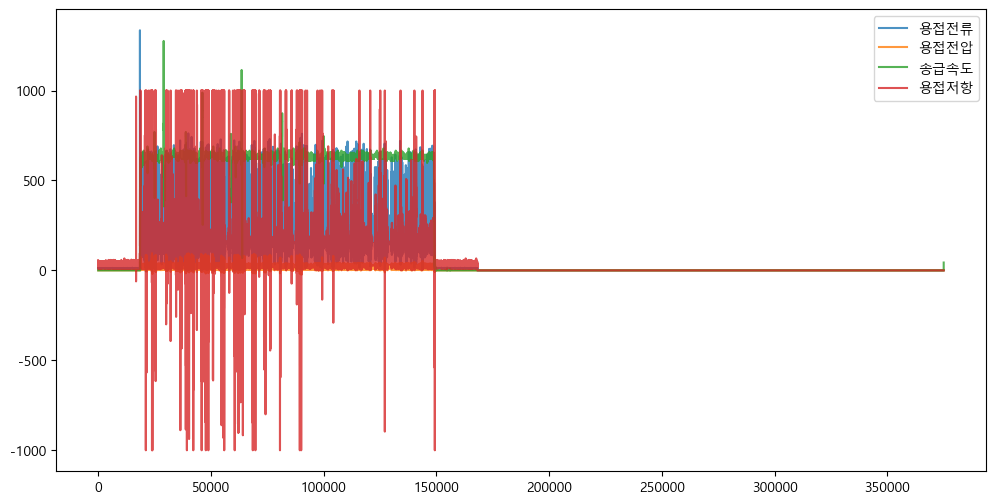

In [4]:
# 그래프 그리기
plt.figure(figsize=(12, 6))

# 인덱스(순서)를 x축으로 하고, 각 컬럼의 데이터를 y축으로 하여 선 그래프 작성
plt.plot(df.index, df['용접전류'], label='용접전류', alpha=0.8)

plt.plot(df.index, df['용접전압'], label='용접전압', alpha=0.8)
plt.plot(df.index, df['송급속도'], label='송급속도', alpha=0.8)

plt.plot(df.index, df['용접저항'], label='용접저항', alpha=0.8)
plt.legend()
plt.show()

In [5]:
sensors = df.values.copy()

# 초기 1000 rows 제거 (0 ~ 0.4초)
sensors = sensors[1000:]

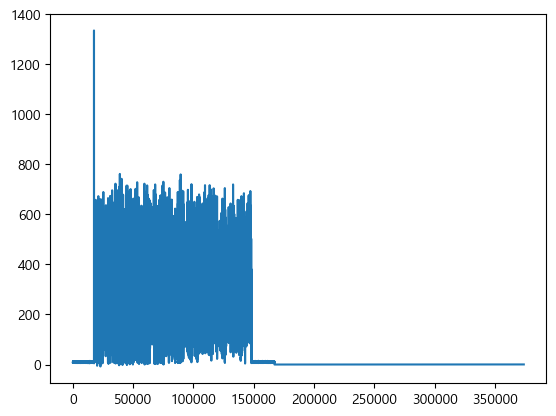

In [6]:
plt.plot(sensors[:, 0])

In [7]:
# int(2500/30 * gt_heatmap.shape[0]) / 2500

# gt_heatmap.shape[0] # 1517개의 snapshot

<Axes: >

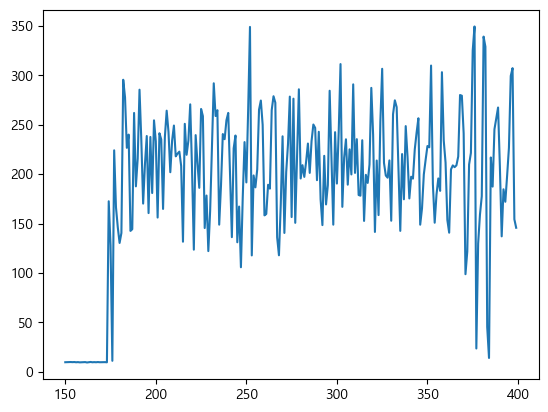

In [84]:
df_current = df['용접전류'].copy()
df_current = df_current[1000:].reset_index()['용접전류'] # 0.4초구간 제거
# 100개씩 그룹화하여 평균 계산
df_current_grouped = df_current.groupby(df_current.index // 100).mean()

df_current_grouped[150:400].plot()

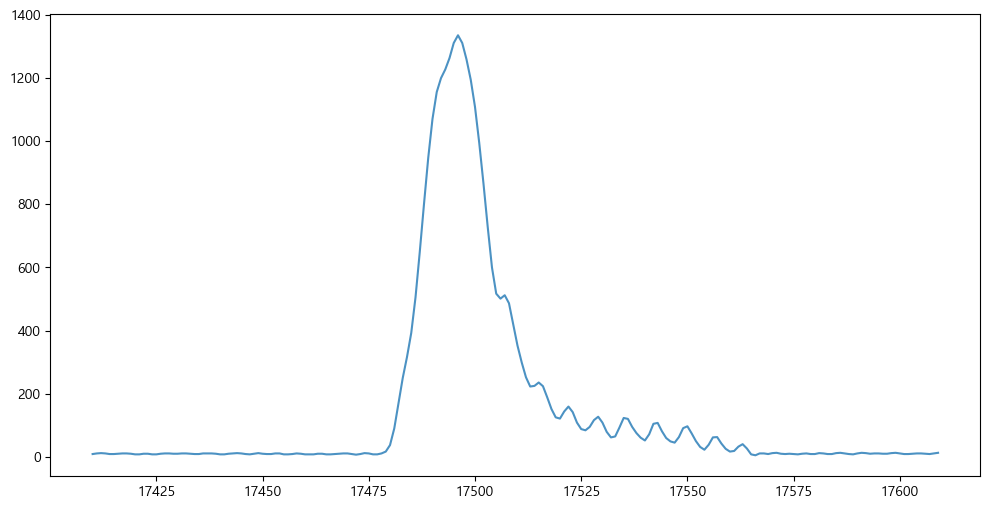

In [85]:
plt.figure(figsize=(12, 6))

df_current.iloc[17410:17410+200].plot(subplots=True, figsize=(12, 10), alpha=0.8)
plt.show()

In [96]:
df_current_grouped[1481:1483]

1481    120.830078
1482     33.378912
Name: 용접전류, dtype: float64

np.float64(120.830078)

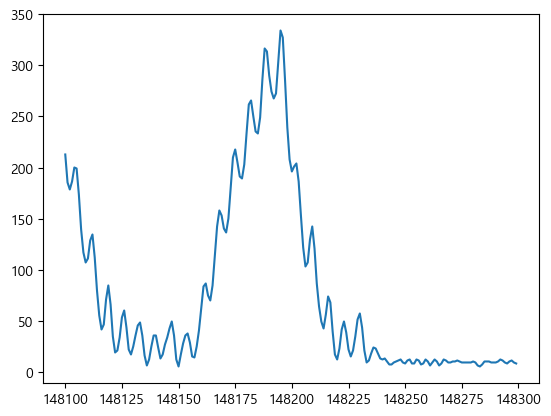

In [99]:
df_current[148100:148300].plot()
df_current[148100:148200].mean()

In [87]:
df_current[df_current > 50.0]

17481      89.8438
17482     170.8984
17483     250.0000
17484     316.4063
17485     392.5781
            ...   
148215     56.6406
148216     74.2188
148217     68.3594
148229     51.7578
148230     57.6172
Name: 용접전류, Length: 125297, dtype: float64

In [108]:
int((148230 - 17481) / 2500 * 25)

1307

In [88]:
df_current_grouped[df_current_grouped > 50.0]

174     172.490241
175     127.812509
177     224.013680
178     166.464853
179     146.181643
           ...    
1477    212.724616
1478    206.337897
1479    252.812502
1480    163.261722
1481    120.830078
Name: 용접전류, Length: 1304, dtype: float64

<Figure size 1200x600 with 0 Axes>

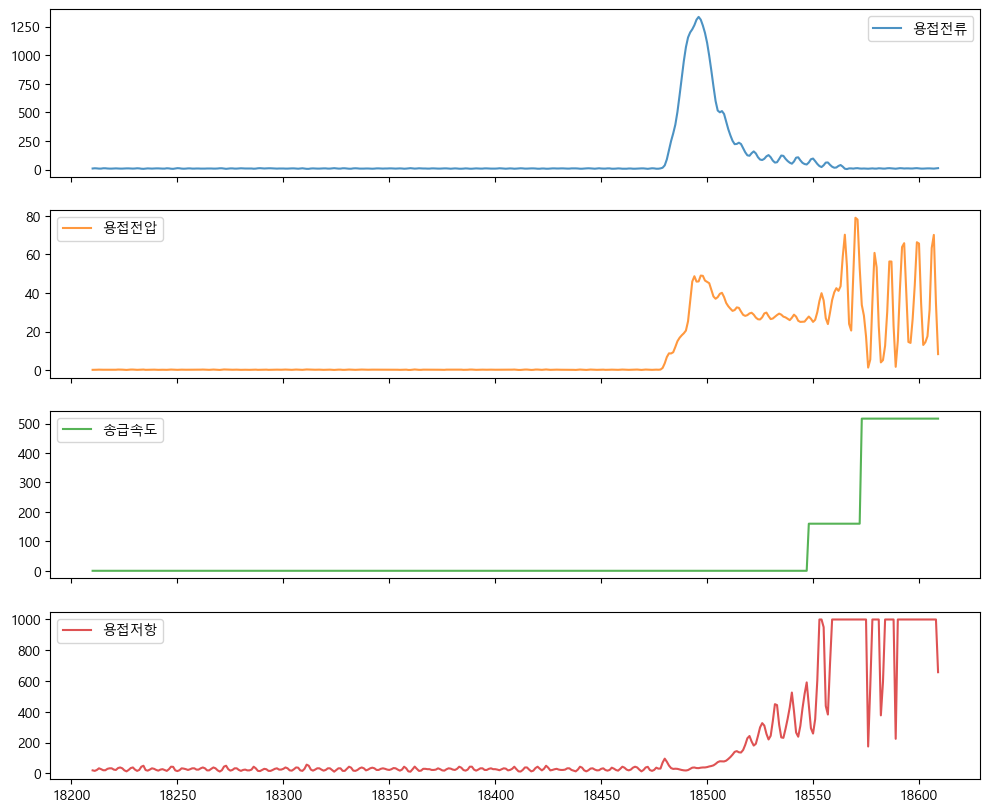

In [14]:
plt.figure(figsize=(12, 6))

df.iloc[18210:18210+400].plot(subplots=True, figsize=(12, 10), alpha=0.8)
plt.show()


In [14]:
wire_speed = df.iloc[100:-100, 2]
wire_speed

100       0.0
101       0.0
102       0.0
103       0.0
104       0.0
         ... 
374895    0.0
374896    0.0
374897    0.0
374898    0.0
374899    0.0
Name: 송급속도, Length: 374800, dtype: float64

<Axes: >

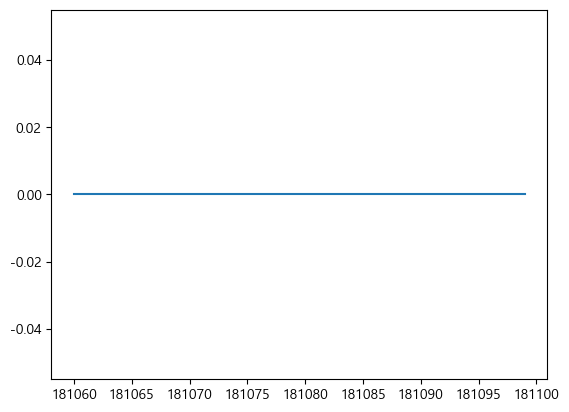

In [15]:
wire_speed.iloc[180960:181000].plot()

In [16]:
wire_speed[wire_speed > 0.0][-100:]

162748    91.6016
162749    91.6016
162750    91.6016
162751    91.6016
162752    91.6016
           ...   
162918    10.9375
162919    10.9375
162920    10.9375
162921    10.9375
162922    10.9375
Name: 송급속도, Length: 100, dtype: float64

In [17]:
df[df.iloc[:, 2] != 0.0].shape[0] / 2500

57.8304

<Axes: >

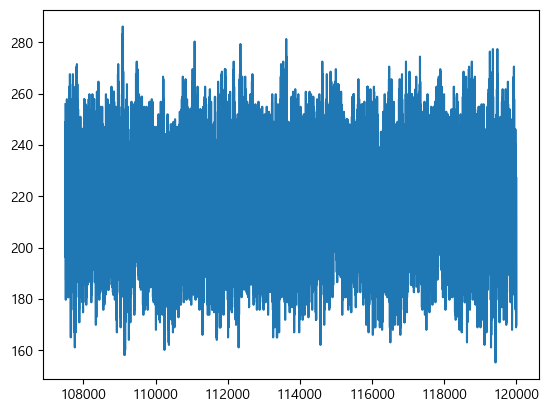

In [18]:
c = 25
idx = 45000 + c*2500
df['용접전류'].iloc[idx:idx+2500*5].plot()

In [19]:
df[df.iloc[:, 2] != 0.0].iloc[:-1, :]

,용접전류,용접전압,송급속도,용접저항
18273,74.2188,30.6152,125.7813,412.5000
18274,103.5156,32.4707,125.7813,313.6793
18275,124.0234,31.3477,125.7813,252.7559
18276,113.2813,28.7598,125.7813,253.8793
18277,89.8438,28.2227,125.7813,314.1304
...,...,...,...,...
162918,9.7656,49.2676,10.9375,1000.0000
162919,8.7891,16.5527,10.9375,1000.0000
162920,6.8359,-3.0762,10.9375,-450.0000
162921,5.8594,11.4258,10.9375,1000.0000


In [20]:
ret = df.describe()['송급속도'].to_dict()
ret['name'] = '송급속도'

json_str = json.dumps(ret, indent=2, ensure_ascii=False)
json_str


'{\n  "count": 375000.0,\n  "mean": 230.45083866879995,\n  "std": 291.35020720684025,\n  "min": 0.0,\n  "25%": 0.0,\n  "50%": 0.0,\n  "75%": 597.4609,\n  "max": 678.125,\n  "name": "송급속도"\n}'

In [21]:
def extract_welding_features(df, fps=25, sensor_hz=2500, current_threshold=50):
    """
    고주파 용접 센서 데이터를 영상 FPS에 맞춰 물리 기반 파생 변수를 포함한 통계 피처로 변환하는 함수

    Parameters:
    - df: ['용접전류', '용접전압', '용접저항', '송급속도'] 컬럼을 포함하는 DataFrame
    - fps: 동기화할 타겟 영상의 초당 프레임 수 (기본 25)
    - sensor_hz: 센서 데이터 수집 주파수 (기본 2500)
    - current_threshold: 용접 시작/종료를 판별할 전류 기준값 (기본 50A)

    Returns:
    - values: 영상 프레임별 피처 배열 (N, 22)
    - columns: 피처 컬럼명
    - start_idx: 원본 데이터에서의 용접 시작 인덱스 (영상 트리밍용)
    - end_idx: 원본 데이터에서의 용접 종료 인덱스 (영상 트리밍용)
    """

    # 1. 용접 유효 구간 추출 (Trimming)
    # valid_indices = df[df['용접전류'] >= current_threshold].index
    
    valid_indices = df[df['송급속도'] > 0].index
    valid_indices = valid_indices[:-1]

    if len(valid_indices) == 0:
        raise ValueError("전류가 50A 이상인 구간이 없습니다.")

    start_idx = int(valid_indices[0] - 5*sensor_hz/fps)
    # valid_indices[0]
    end_idx = valid_indices[-1]

    df_trimmed = df.iloc[start_idx:end_idx + 1].copy()
    df_trimmed.reset_index(drop=True, inplace=True)

    # 2. 영상 프레임 인덱스 매핑 (Synchronization)
    df_trimmed['Frame_Index'] = (df_trimmed.index * fps) // sensor_hz

    # 3. 원시 데이터 레벨 파생 변수: 순간 입열량 (Power)
    df_trimmed['입열량(Power)'] = df_trimmed['용접전류'] * df_trimmed['용접전압']

    # 4. 프레임 단위 통계 집계 (Window Aggregation)
    target_cols = ['용접전류', '용접전압', '용접저항', '송급속도', '입열량(Power)']
    agg_funcs = ['mean', 'std', 'max', 'min']

    df_features = df_trimmed.groupby('Frame_Index')[target_cols].agg(agg_funcs)
    df_features = df_features.fillna(0)
    df_features.columns = [f"{col}_{stat}" for col, stat in df_features.columns]

    # 5. 프레임 레벨 파생 변수 계산
    epsilon = 1e-5

    # (1) 아크 불안정성 지수 (Arc Instability Index = 전류 CV + 전압 CV)
    current_cv = df_features['용접전류_std'] / (df_features['용접전류_mean'] + epsilon)
    voltage_cv = df_features['용접전압_std'] / (df_features['용접전압_mean'] + epsilon)
    df_features['Arc_Instability'] = current_cv + voltage_cv

    # (2) 열관성 (Heat Inertia - EMA of Power_mean)
    df_features['Heat_Inertia(EMA)'] = df_features['입열량(Power)_mean'].ewm(span=15, adjust=False).mean()

    return df_features, df_features.columns, start_idx, end_idx

In [22]:
features_df, df_columns, video_start, video_end = extract_welding_features(df, fps=25, sensor_hz=2500, current_threshold=50)
# 
print(f"추출된 프레임 수: {len(features_df)}")
print(f"Input Shape: {features_df.shape}") # (N_Frames, 16)
print(f"영상 자르기 시작 시간: {video_start / 2500:.2f}초")
print(f"영상 자르기 종료 시간: {video_end / 2500:.2f}초")
print(f"시작 프레임: {video_start}")
print(f"종료 프레임: {video_end}")

추출된 프레임 수: 1452
Input Shape: (1452, 22)
영상 자르기 시작 시간: 7.11초
영상 자르기 종료 시간: 65.17초
시작 프레임: 17773
종료 프레임: 162922


In [23]:
(video_end - video_start) / 2500

np.float64(58.0596)

In [24]:
raw_video = np.load(f'crop_heatmaps_{TF_case}.npy')  # (1684, 14, 22)

raw_video.shape

(1684, 30, 30)

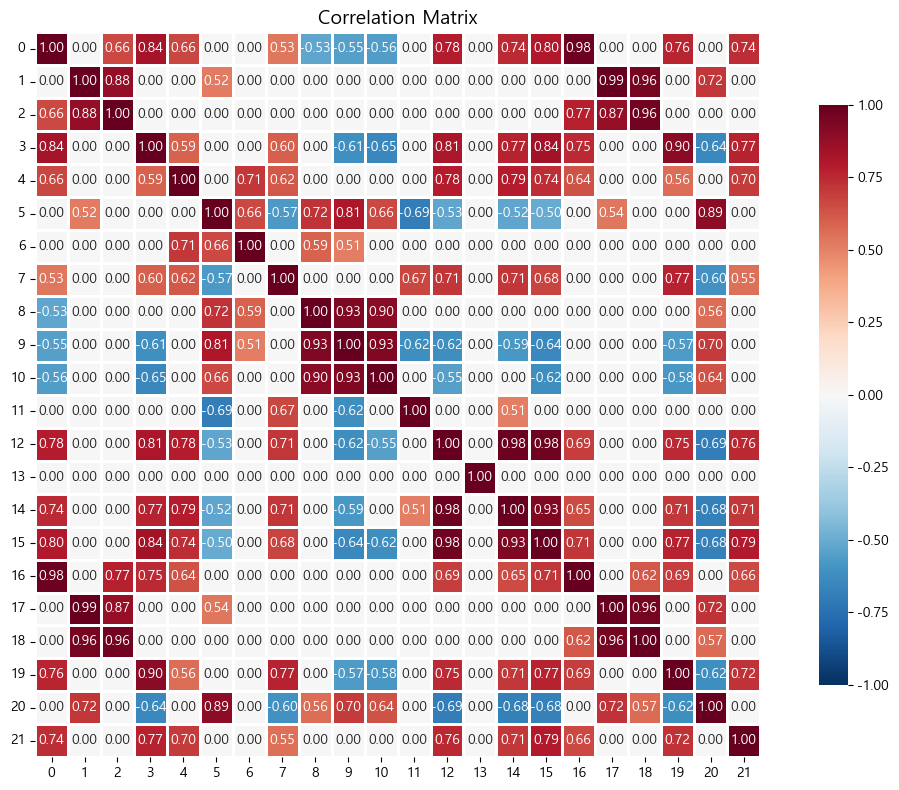

In [25]:
import numpy as np
import seaborn as sns

# 예시 데이터
X = features_df

# feature 간 correlation
corr_matrix = np.corrcoef(X, rowvar=False)

# 유의미한 상관관계 시각화
sign_corr_matrix = corr_matrix.copy()
sign_corr_matrix[np.abs(corr_matrix) < 0.5] = 0.0

plt.figure(figsize=(12, 8))

sns.heatmap(
    sign_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
sign_corr_matrix.shape

(22, 22)

In [27]:
# ==========================================
# 실행 파이프라인 (Data Processing Pipeline)
# ==========================================

# 1. 원본 데이터 로드
# raw_video = np.load('crop_heatmaps_TF052_test.npy')  # (2837, 14, 22)
sensor_df = df.copy()
sensor_df.columns = [col.strip() for col in sensor_df.columns]

# 2. 물리적 기준점 및 파라미터 설정
v_start = 391          # 아크 점화 프레임 (타겟 시작점)
v_cool_end = 1908      # 800도 이하로 식은 프레임 (타겟 종료점)
s_start = 17308        # 센서 아크 점화 Row
window_size = 5        # 입력 윈도우 사이즈 (5 프레임)
rows_per_frame = 100   # 1프레임 = 100 Rows (2500Hz / 25FPS)

# ---------------------------------------------------------
# [중요] 타겟과 입력 윈도우를 맞추기 위한 데이터 슬라이싱
# ---------------------------------------------------------
# 타겟 GT는 391 프레임부터 시작합니다.
# 이 타겟을 예측하기 위해서는 391 프레임을 포함한 과거 5프레임 (387, 388, 389, 390, 391)의 센서 데이터가 필요합니다.
# 따라서 영상과 센서 데이터를 모두 387 프레임부터 자릅니다.

# (1) 필요 프레임 범위 계산
input_start_frame = v_start - (window_size - 1)  # 387
target_end_frame = v_cool_end                    # 1908
total_needed_frames = target_end_frame - input_start_frame + 1  # 1522장

# (2) 센서 데이터 슬라이싱 (387 프레임에 해당하는 Row부터 시작)
row_start_idx = s_start - ((window_size - 1) * rows_per_frame)  # 17308 - 400 = 16908
row_end_idx = row_start_idx + (total_needed_frames * rows_per_frame)

sliced_sensor_df = sensor_df.iloc[row_start_idx : row_end_idx].reset_index(drop=True)

# (3) 열화상 영상 슬라이싱
# sliced_gt_array = raw_video[input_start_frame : target_end_frame + 1]


# ---------------------------------------------------------
# 모델 입력용 데이터셋 생성
# ---------------------------------------------------------

# 피처 추출 (Shape: 1522, 22)
features_2d, feature_indices = extract_physics_features(sliced_sensor_df, rows_per_frame=rows_per_frame)

# Time-window 스태킹 적용
# X_seq, Y_target = create_time_windows(features_2d, sliced_gt_array, window_size=window_size)

print("=== 데이터셋 생성 완료 ===")
# print(f"Input X shape:  {X_seq.shape}    -> (1518 샘플, 5 프레임, 22 피처)")
# print(f"Target Y shape: {Y_target.shape} -> (1518 샘플, 14 Height, 22 Width)")

# np.save('X_TF052_dataset.npy', X_seq)
# np.save('Y_TF052_dataset.npy', Y_target)

NameError: name 'extract_physics_features' is not defined

In [28]:
def create_time_windows(features_array, window_size=5):
    """
    (N, Features) 데이터를 (N-W+1, W, Features) 형태의 Time-Window 텐서로 변환하는 함수
    """
    X = []
    
    # 시계열 슬라이딩 윈도우 생성
    for i in range(len(features_array) - window_size + 1):
        # i 부터 i+window_size-1 까지의 센서 데이터 묶음 (Input)
        window_X = features_array[i : i + window_size]
        
        X.append(window_X)
    return np.array(X)

In [29]:
df

,용접전류,용접전압,송급속도,용접저항
0,7.8125,0.2930,0.0000,37.5000
1,6.8359,0.3418,0.0000,50.0000
2,6.8359,0.2930,0.0000,42.8571
3,6.8359,0.2930,0.0000,42.8571
4,5.8594,0.3418,0.0000,58.3333
...,...,...,...,...
374995,0.0000,0.0000,0.0000,0.0000
374996,0.0000,0.0000,0.0000,0.0000
374997,0.0000,0.0000,0.0000,0.0000
374998,0.0000,0.0000,0.0000,0.0000


In [43]:
import numpy as np

def make_dataset(TF_case, txt_path):
    # 1. 데이터 로드
    heatmaps = np.load(f'crop_heatmaps_{TF_case}.npy')
    df = pd.read_csv(txt_path, header=1, names=columns, encoding='unicode_escape')
    sensors = df.values.copy()

    # 2. 주파수(FPS/Hz) 설정
    fps = 25.0   # 약 30.24 FPS
    sensor_hz = 2500.0
    pre_frame = 4

    # 3. 신호 추출 및 시간 축 생성
    max_temps = heatmaps.astype(np.float32).max(axis=(1, 2))
    current = sensors[:, 0]

    time_h = np.arange(len(max_temps)) / fps
    time_s = np.arange(len(current)) / sensor_hz

    # 4. 이벤트(용접 시작) 지점 탐색
    # 센서: 전류가 20A 이상으로 튀어오르는 첫 시점
    start_sensor_idx = np.where(current > 50.0)[0][0] - pre_frame*100
    start_sensor_time = time_s[start_sensor_idx + pre_frame*100]

    # 열화상: 최고 온도가 급격히 상승(예: 100도 이상)하는 첫 시점
    start_heatmap_idx = np.where(max_temps > 100.0)[0][0]
    start_heatmap_time = time_h[start_heatmap_idx]

    print(f"센서 수집 버튼 누른 후 용접 시작까지 걸린 시간: {start_sensor_time:.3f}초")
    print(f"카메라 녹화 버튼 누른 후 용접 시작까지 걸린 시간: {start_heatmap_time:.3f}초")
    print(f"발생한 시차(Offset): {abs(start_heatmap_time - start_sensor_time):.3f}초")

    # 5. GT 매칭을 위한 동기화 (예: 용접 시작부터 끝까지 매칭)
    # 센서에서 용접이 종료되는 시점(전류가 다시 10A 이하로 떨어짐)을 기준으로 삼음
    end_sensor_idx = np.where(current > 50.0)[0][-1]
    weld_duration = time_s[end_sensor_idx] - start_sensor_time # 실제 용접 수행 시간(초)

    print(f" 실제 용접 수행 시간(초): {weld_duration:.4f}")
    # 매칭할 프레임 길이 계산
    heatmap_weld_frames = int(weld_duration * fps)

    # 6. 최종적으로 매칭된 데이터 크롭(Crop)
    # 열화상: 시작 인덱스 ~ (시작 인덱스 + 용접 프레임수)
    aligned_heatmaps = heatmaps[start_heatmap_idx : start_heatmap_idx + heatmap_weld_frames]

    print(f"센서 시작 : {start_sensor_idx}, 센서 종료 : {end_sensor_idx}, \
            열화상 시작 :{start_heatmap_idx}, 열화상 종료 : {start_heatmap_idx + heatmap_weld_frames}")
    print(f"센서 구간 길이 {end_sensor_idx - start_sensor_idx}, \
           열화상 구간 길이 : {len(aligned_heatmaps)}")

    # 센서: 시작 시간 ~ 종료 시간 사이의 데이터를 FPS(25Hz)에 맞춰 리샘플링하여 매칭
    matched_sensor_list = []
    for i in range(heatmap_weld_frames+pre_frame):
        # 열화상 1프레임에 해당하는 시간
        target_time_in_weld = i / fps 
        
        # 센서 데이터상에서 해당 시간의 인덱스를 계산
        # (용접 시작 인덱스 + 타겟 시간에 해당하는 센서 인덱스 이동량)
        sensor_target_idx = start_sensor_idx + int(target_time_in_weld * sensor_hz)
        # print(sensor_target_idx)
        # 카메라 1프레임 동안 들어온 센서 데이터(100개) 묶음의 평균
        chunk_start = sensor_target_idx
        chunk_end = chunk_start + int(sensor_hz / fps)
        
        sensor_chunk_mean = sensors[chunk_start:chunk_end].mean(axis=0)
        matched_sensor_list.append(sensor_chunk_mean)

    aligned_sensors = np.array(matched_sensor_list)

    print("-" * 40)
    print(f"매칭 완료된 열화상 데이터 Shape: {aligned_heatmaps.shape}")
    print(f"매칭 완료된 센서 데이터 Shape  : {aligned_sensors.shape}")

    window_sensors = create_time_windows(aligned_sensors, window_size=5)
    
    print(f"윈도우 변환된 센서 데이터 Shape  : {window_sensors.shape}")

    np.save(f"aligned_heatmap_{TF_case}.npy", aligned_heatmaps)
    np.save(f"window_sensors_{TF_case}.npy", window_sensors)


18210 162784 376 1821


In [44]:
data_files = [
    "TF033",
    "TF034",
    "TF035",
]

data_path = "../../data/raw/T-Fillet/TF031_060"


for case in data_files:
    TF_Pass = f"{case}_1PASS"
    txt_path = f"{data_path}/{case}/{TF_Pass}/{case}_wellteq.txt"
    make_dataset(case, txt_path)

센서 수집 버튼 누른 후 용접 시작까지 걸린 시간: 7.284초
카메라 녹화 버튼 누른 후 용접 시작까지 걸린 시간: 0.000초
발생한 시차(Offset): 7.284초
 실제 용접 수행 시간(초): 57.8296
센서 시작 : 17810, 센서 종료 : 162784,             열화상 시작 :0, 열화상 종료 : 1445
센서 구간 길이 144974,            열화상 구간 길이 : 1445
----------------------------------------
매칭 완료된 열화상 데이터 Shape: (1445, 30, 30)
매칭 완료된 센서 데이터 Shape  : (1449, 4)
윈도우 변환된 센서 데이터 Shape  : (1445, 5, 4)
센서 수집 버튼 누른 후 용접 시작까지 걸린 시간: 12.661초
카메라 녹화 버튼 누른 후 용접 시작까지 걸린 시간: 0.000초
발생한 시차(Offset): 12.661초
 실제 용접 수행 시간(초): 61.5484
센서 시작 : 31252, 센서 종료 : 185523,             열화상 시작 :0, 열화상 종료 : 1538
센서 구간 길이 154271,            열화상 구간 길이 : 1538
----------------------------------------
매칭 완료된 열화상 데이터 Shape: (1538, 30, 30)
매칭 완료된 센서 데이터 Shape  : (1542, 4)
윈도우 변환된 센서 데이터 Shape  : (1538, 5, 4)
센서 수집 버튼 누른 후 용접 시작까지 걸린 시간: 12.175초
카메라 녹화 버튼 누른 후 용접 시작까지 걸린 시간: 0.000초
발생한 시차(Offset): 12.175초
 실제 용접 수행 시간(초): 52.2204
센서 시작 : 30038, 센서 종료 : 160989,             열화상 시작 :0, 열화상 종료 : 1305
센서 구간 길이 130951,            열화상 구간 길이 : 130

In [26]:
data = np.load(r"C:\Users\82104\Desktop\weld-pool-prediction\notebooks\seonyang\dataset\window_sensors_TF031.npy")
first_sample = data[100]

In [30]:
columns

['용접전류', '용접전압', '송급속도', '용접저항']

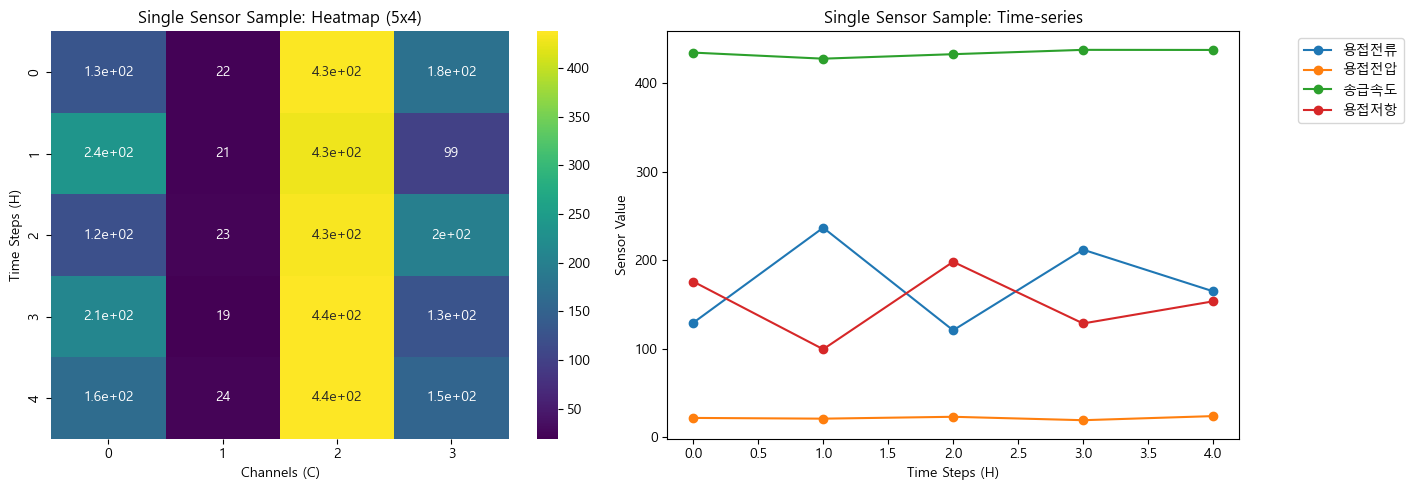

In [35]:
import seaborn as sns

# 3. 시각화 설정

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Heatmap 시각화: 시점(H)과 채널(C) 간의 데이터 값 분포 확인
sns.heatmap(first_sample, annot=True, cmap='viridis', ax=axes[0])
axes[0].set_title('Single Sensor Sample: Heatmap (5x4)')
axes[0].set_xlabel('Channels (C)')
axes[0].set_ylabel('Time Steps (H)')

# (B) Line Plot 시각화: 각 채널별 시간에 따른 변화 추이 확인
for i in range(4):
    axes[1].plot(first_sample[:, i], marker='o', label=f"{columns[i]}")
axes[1].set_title('Single Sensor Sample: Time-series')
axes[1].set_xlabel('Time Steps (H)')
axes[1].set_ylabel('Sensor Value')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.show()

C:\Users\82104\AppData\Local\Temp\ipykernel_37584\94741802.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([reshaped_data[i] for i in range(C)], labels=features, vert=False, patch_artist=True)


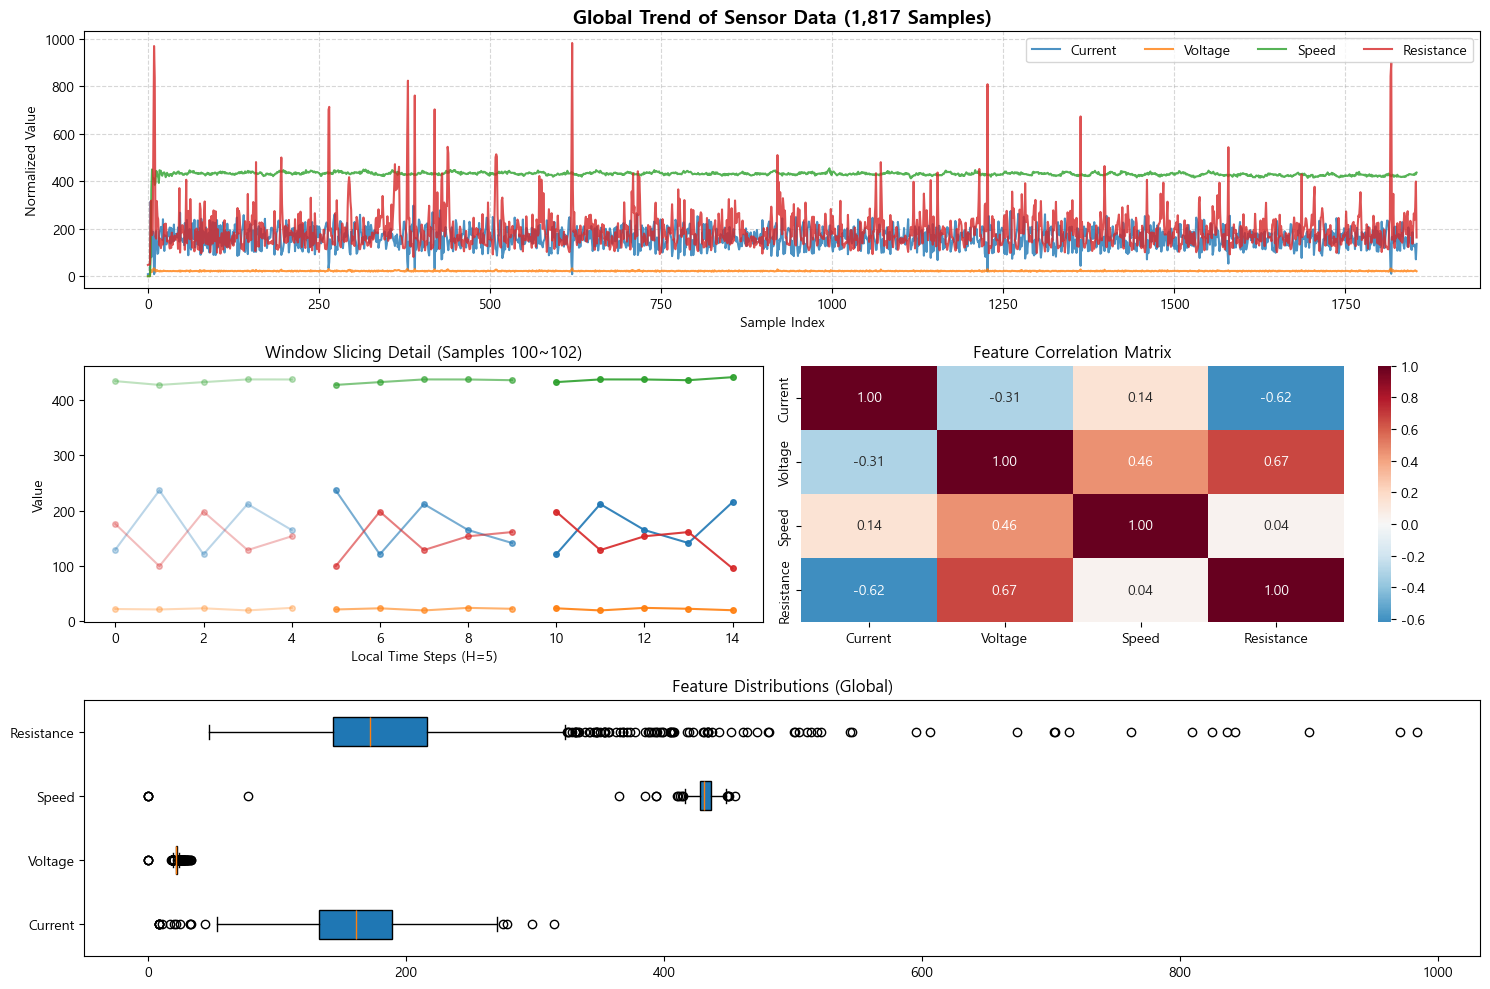

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. 데이터 정의 (제시해주신 규격 반영)
N, H, C = 1817, 5, 4
features = ['Current', 'Voltage', 'Speed', 'Resistance']
sensor_data = data  # 실제 데이터를 여기에 대입하세요.

# 2. 시각화 레이아웃 설정
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2)

# --- (1) Global Trend (1,817 Samples) ---
ax1 = fig.add_subplot(gs[0, :])
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i in range(C):
    # 각 윈도우의 첫 번째 값을 연결하여 전체 트렌드 시각화
    ax1.plot(sensor_data[:, 0, i], label=features[i], color=colors[i], alpha=0.8)
ax1.set_title('Global Trend of Sensor Data (1,817 Samples)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Normalized Value')
ax1.legend(loc='upper right', ncol=4)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- (2) Window Detail (5 steps per window) ---
ax2 = fig.add_subplot(gs[1, 0])
sample_idx = 100 # 시각화할 샘플 번호
for i in range(C):
    # 연속된 3개의 윈도우(5 steps씩)를 점으로 연결해 시각화
    for offset in range(3):
        win = sensor_data[sample_idx + offset, :, i]
        x_range = np.arange(offset * 5, (offset + 1) * 5)
        ax2.plot(x_range, win, marker='o', markersize=4, color=colors[i], alpha=0.3 + offset*0.3)
ax2.set_title(f'Window Slicing Detail (Samples {sample_idx}~{sample_idx+2})', fontsize=12)
ax2.set_xlabel('Local Time Steps (H=5)')
ax2.set_ylabel('Value')

# --- (3) Feature Correlation ---
ax3 = fig.add_subplot(gs[1, 1])
corr_matrix = np.corrcoef(sensor_data[:, 0, :].T)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", xticklabels=features, yticklabels=features, cmap='RdBu_r', center=0, ax=ax3)
ax3.set_title('Feature Correlation Matrix', fontsize=12)

# --- (4) Global Distributions ---
ax4 = fig.add_subplot(gs[2, :])
reshaped_data = sensor_data[:, 0, :].T
ax4.boxplot([reshaped_data[i] for i in range(C)], labels=features, vert=False, patch_artist=True)
ax4.set_title('Feature Distributions (Global)', fontsize=12)

plt.tight_layout()
plt.show()